In [1]:
print("Supervised Modeling Notebook")

Supervised Modeling Notebook


In [2]:
# Load Cleaned Data
import pandas as pd

df = pd.read_csv("../data/cleaned_data.csv")

df.head()

,product_id,category,price,quantity,order_date,shipping_date,delivery_status,payment_method,device_type,channel,shipping_address,billing_address,customer_segment,order_month,order_day,shipping_time
0,845,Books,45.95,4,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,PayPal,Mobile,Paid Search,"976 Kevin Station, Davidmouth, Hawaii 92563","38182 Ariel Expressway, Campbellland, Oklahoma...",VIP,4,20,7
1,995,Electronics,403.17,3,2024-04-20 14:59:58.897063,2024-04-22 14:59:58.897063,Delivered,PayPal,Mobile,Paid Search,"72166 Cunningham Crescent, East Nicholasside, ...","38199 Edwin Plain, Johnborough, Maine 81826",Returning,4,20,2
2,997,Beauty,317.45,2,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,Credit Card,Mobile,Email,"2446 Johnson Junctions, Lynchtown, Minnesota 7...","58086 Smith Stream Suite 994, Lake Pamelabury,...",Returning,4,20,7
3,385,Home,24.08,3,2024-04-20 14:59:58.897063,2024-04-24 14:59:58.897063,Shipped,PayPal,Tablet,Social,"3113 Jessica Knolls, North Joshuafort, Alabama...","484 Palmer Harbors Apt. 866, Dustintown, Nebra...",VIP,4,20,4
4,31,Clothing,494.90,1,2024-04-20 14:59:58.897063,2024-04-25 14:59:58.897063,Delivered,PayPal,Tablet,Organic,"58196 Burgess Heights Suite 315, Douglasland, ...","67094 Schaefer Villages Suite 369, Douglasches...",VIP,4,20,5


In [3]:
# Define Features & Target (Regression)

X = df.drop(columns=["price"])
y = df["price"]

In [4]:
# Identify Column Types

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [5]:
# Create Preprocessing Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [6]:
# Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
# Build Regression Model (SGD)

from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDRegressor

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", SGDRegressor(
        learning_rate='constant',
        eta0=0.01,
        max_iter=1000
    ))
])

In [8]:
# Train Model

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [9]:
# Predict

y_pred = model.predict(X_test)

In [10]:
# Evaluate Model

from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)

MSE: 21978.447320874675
MAE: 126.59560654004093


In [11]:
# Cross Validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')

print("Average MSE:", -scores.mean())

Average MSE: 20291.019408943917


In [12]:
# EXPERIMENT part

models = [
    SGDRegressor(eta0=0.001, max_iter=500),
    SGDRegressor(eta0=0.01, max_iter=1000),
    SGDRegressor(eta0=0.1, max_iter=2000)
]

for m in models:
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", m)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    print("Model:", m)
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("------")

C:\Users\JAYASANKI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Model: SGDRegressor(eta0=0.001, max_iter=500)
MSE: 20721.38331262511
MAE: 124.04079222067047
------


C:\Users\JAYASANKI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Model: SGDRegressor()
MSE: 21873.83901903534
MAE: 126.50004801712939
------
Model: SGDRegressor(eta0=0.1, max_iter=2000)
MSE: 21902.859874224076
MAE: 126.56906808155057
------


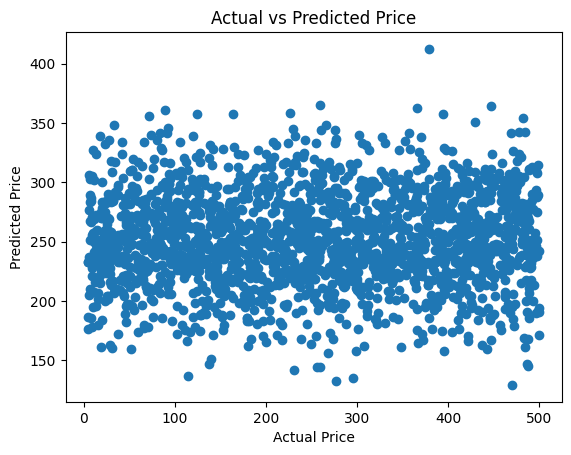

In [13]:
# Visualization

import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

* Learning Rate

Small learning rate → slow but stable  
Large learning rate → fast but unstable


* Epochs

Low epochs → underfitting  
High epochs → better learning but may overfit


* MSE vs MAE

MSE → penalizes big errors  
MAE → average error


* Business Impact

Wrong price prediction can cause financial loss or reduce customer satisfaction.

